In [8]:
import numpy as np
import moments 
import dpluspy
import matplotlib.pyplot as plt 
import matplotlib 
import msprime
import demes 
import demesdraw
import moments
import scipy
from matplotlib.transforms import ScaledTranslation

In [2]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5
lw = 0.8

In [3]:
Nref = 1e4

def get_structure_model(params):
    vX, vY, v1, t0, t1, f, M = params
    NX = Nref * vX
    NY = Nref * vY 
    N1 = Nref * v1 
    T0 = 2 * Nref * t0 
    T1 = 2 * Nref * t1
    m = M / (4 * Nref)
    builder = demes.Builder()
    builder.add_deme("Anc", epochs=[{"start_size": Nref, "end_time": T0}])
    builder.add_deme("X", ancestors=["Anc"], 
                     epochs=[{"start_size": NX, "end_time": T1}])
    builder.add_deme("Y", ancestors=["Anc"], 
                     epochs=[{"start_size": NY, "end_time": T1}])
    builder.add_deme("A", ancestors=["X", "Y"], proportions=[f, 1 - f],
                     start_time=T1, 
                     epochs=[{"start_size": N1, "end_time": 0}])
    if m > 0:
        builder.add_migration(rate=m, demes=["X", "Y"])
    graph = builder.resolve()
    return graph


def compute_rate_trajectory(graph, ts, sample):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, {sample: 2})
    return rates


def get_panmictic_model(ts, rates):
    Nes = 1 / (2 * np.array(rates))
    _ts = np.flip(ts)
    _Nes = np.flip(Nes)
    epochs = [
        {"start_size": Ne, "end_time": t} for Ne, t in zip(_Nes, _ts)
    ]
    builder = demes.Builder()
    builder.add_deme("A", epochs=epochs)
    graph = builder.resolve()
    return graph


_models_cache = {}


def get_model_curves(params, rs, u=1e-8, n_ts=50):
    model_key = (tuple(params), tuple(list(rs)), u, n_ts)
    if model_key in _models_cache:
        struc_exp, panmix_exp = _models_cache[model_key]
        return struc_exp, panmix_exp
    T0 = params[3] * 2 * Nref
    ts = np.linspace(0, T0 * 1.05, n_ts)
    struc_model = get_structure_model(params)
    struc_exp = moments.Demes.LD(
        struc_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    rates = compute_rate_trajectory(struc_model, ts, "A")
    panmix_model = get_panmictic_model(ts, rates)
    panmix_exp = moments.Demes.LD(
        panmix_model, sampled_demes=["A"], r=rs, u=u).H2(0)
    _models_cache[model_key] = (struc_exp, panmix_exp)
    return struc_exp, panmix_exp

In [4]:
colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]


def plot_strucpanel(
    ax, 
    params_s, 
    labels,
    rs, 
    u=1e-8, 
    n_ts=50, 
    struc_kwargs={}, 
    pan_kwargs={}
):
    """
    Plot a comparison of panmictic/structured model expectations
    :param params_s: list of lists/tuples holding parameters for struc. model
    """
    rhos = 4 * Nref * rs
    for ii, params in enumerate(params_s):
        color = colors[ii]
        label = labels[ii]
        struc_exp, panmix_exp = get_model_curves(params, rs, u=u, n_ts=n_ts)
        ax.plot(rhos, struc_exp, color=color, label=label, lw=lw, 
                **struc_kwargs)
        #ax.plot(rhos, panmix_exp, "--", color=color, lw=lw, **pan_kwargs)
        ax.plot(rhos, panmix_exp, "--o", color=color, lw=lw,
                markersize=3, **pan_kwargs)
        #ax.scatter(rhos, panmix_exp, color=color, s=10, lw=lw)
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.legend(framealpha=0, fontsize="small")
    ax.set_ylabel(r"$\mathbb{E}[D^+]$")
    ax.set_xlabel(r"$\rho$")
    return

In [5]:
example_params = (0.5, 0.5, 1, 1.1, 0.1, 0.5, 1e-8)

def plot_schematic_model(ax):
    model = get_structure_model(example_params)
    demesdraw.tubes(
        model,
        positions={"Anc": 0, "A": 0, "X": -1.4e4, "Y": 1.4e4},
        num_lines_per_migration=4,
        colours="tab:blue",
        ax=ax,
        labels=None
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (units of $2N_0$)")
    ax.set_yticks([2.5e4, 5e3], ["$T_0$", "$T_1$"])
    ax.annotate(r"$\nu_0$", [-2000, 22500])
    ax.annotate("$M$", [-1500, 11000])
    ax.annotate(r"$\nu_X$", [-1.6e4, 11000])
    ax.annotate(r"$\nu_Y$", [1.2e4, 11000])
    ax.annotate(r"$\nu_1$", [-2000, 500])
    ax.annotate("$f$", [-9500, 500])
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_schematic_panmix_model(ax):
    _model = get_structure_model(example_params)
    ts = np.linspace(0, 2.22e4, 21)
    rates = compute_rate_trajectory(_model, ts, "A")
    model = get_panmictic_model(ts, rates)
    demesdraw.tubes(
        model,
        positions={"A": 0},
        num_lines_per_migration=4,
        colours="tab:blue",
        ax=ax,
        labels=None,
        inf_ratio=0.1
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (units of $2N_0$)")
    ax.set_yticks([2.2e4, 2e3], ["$T_0$", "$T_1$"])
    ax.set_xlim(-2.2e4, 2.2e4)
    return 


def plot_coal_rates(ax):
    ts = np.linspace(0, 2.5e4, 101)
    _ts = np.linspace(0, 2.5e4, 21)
    struc_model = get_structure_model(example_params)
    rates = compute_rate_trajectory(struc_model, ts, "A") 
    panmix_model = get_panmictic_model(ts, rates)
    pan_rates = compute_rate_trajectory(panmix_model, _ts, "A")
    ax.plot(ts, rates * 2e4, color="tab:blue", lw=lw, label="structured")
    ax.scatter(_ts, pan_rates * 2e4, color="tab:blue", s=10)
    ax.plot([], [], "--o", color="tab:blue", lw=lw, label="panmictic", 
            markersize=3)
    ax.legend(framealpha=0, fontsize="small")
    ax.set_ylabel(r"$\lambda(t)\times 2N_0$")
    ax.set_xlabel("$t$")
    return

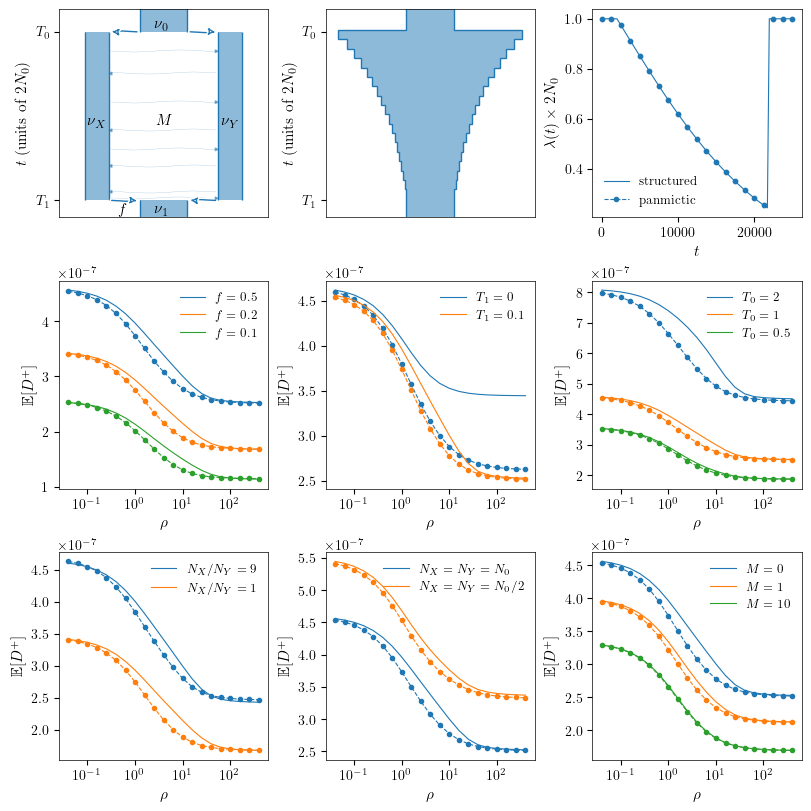

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(8, 8), layout="constrained")
rs = np.logspace(-6, -2, 21)
axs = axs.flat
#for label, ax in axs.items():
#    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
#        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
plot_schematic_model(axs[0])
plot_schematic_panmix_model(axs[1])
axs[0].sharey(axs[1])
plot_coal_rates(axs[2])


params0 = [
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.2, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.1, 0),
]
labels0 = [
    r"$f=0.5$",
    r"$f=0.2$",
    r"$f=0.1$",
]
plot_strucpanel(axs[3], params0, labels0, rs, n_ts=50)


params1 = [
    (0.5, 0.5, 1, 1 + 1e-6, 1e-6, 0.5, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 0)
]
labels1 = [
    r"$T_1 = 0$",
    r"$T_1 = 0.1$",
]
plot_strucpanel(axs[4], params1, labels1, rs, n_ts=50)


params2 = [
    (0.5, 0.5, 1, 2.1, 0.1, 0.5, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 0),
    (0.5, 0.5, 1, 0.6, 0.1, 0.5, 0),
]
labels2 = [
    r"$T_0 = 2$",
    r"$T_0 = 1$",
    r"$T_0 = 0.5$",
]
plot_strucpanel(axs[5], params2, labels2, rs, n_ts=50)


params3 = [
    (0.9, 0.1, 1, 1.1, 0.1, 0.5, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.2, 0),
]
labels3 = [
    r"$N_X/N_Y = 9$",
    r"$N_X/N_Y = 1$",
]
plot_strucpanel(axs[6], params3, labels3, rs, n_ts=50)


params4 = [
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 0),
    (1, 1, 1, 1.1, 0.1, 0.5, 0),
]
labels4 = [
    r"$N_X=N_Y = N_0$",
    r"$N_X=N_Y = N_0/2$",
]
plot_strucpanel(axs[7], params4, labels4, rs, n_ts=50)


params5 = [
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 0),
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 1),
    (0.5, 0.5, 1, 1.1, 0.1, 0.5, 10),
]
labels5 = [
    r"$M = 0$",
    r"$M = 1$",
    r"$M = 10$",
]
plot_strucpanel(axs[8], params5, labels5, rs, n_ts=50)

plt.savefig("figures/figS12.pdf")

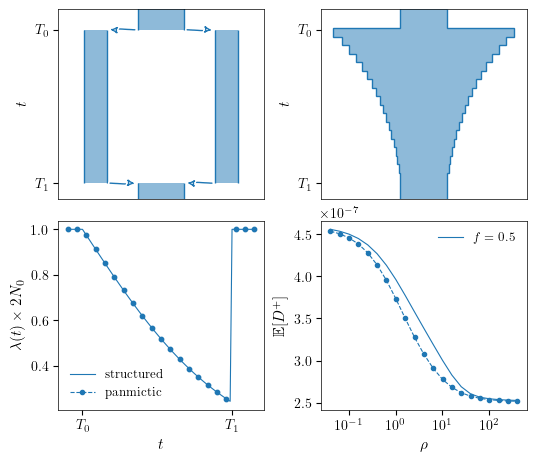

In [6]:
def plot_schematic_model(ax):
    model = get_structure_model(example_params)
    demesdraw.tubes(
        model,
        positions={"Anc": 0, "A": 0, "X": -1.4e4, "Y": 1.4e4},
        num_lines_per_migration=0,
        colours="tab:blue",
        ax=ax,
        labels=None
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (units of $2N_0$)")
    ax.set_yticks([2.5e4, 5e3], ["$T_0$", "$T_1$"])
    ax.set_xlim(-2.2e4, 2.2e4)
    return 

fig, axs = plt.subplots(2, 2, figsize=(5.25, 4.5), layout="constrained")
rs = np.logspace(-6, -2, 21)
axs = axs.flat
plot_schematic_model(axs[0])
plot_schematic_panmix_model(axs[1])
axs[0].sharey(axs[1])
axs[0].set_ylabel("$t$")
axs[1].set_ylabel("$t$")
plot_coal_rates(axs[2])
axs[2].set_xticks([2e3, 2.2e4], ["$T_0$", "$T_1$"])

params0 = [(0.5, 0.5, 1, 1.1, 0.1, 0.5, 0)]
labels0 = ["$f=0.5$"]
plot_strucpanel(axs[3], params0, labels0, rs, n_ts=50)

plt.savefig("extra_figures/structure.png", dpi=244)

In [19]:
equil_model = {}
rhos = [0.1, 1, 10]
for rho in rhos:
    TL, TR = np.array([dpluspy.backward.two_locus_coal(rho) for _ in range(100000)]).T
    equil_model[rho] = (TL, TR)

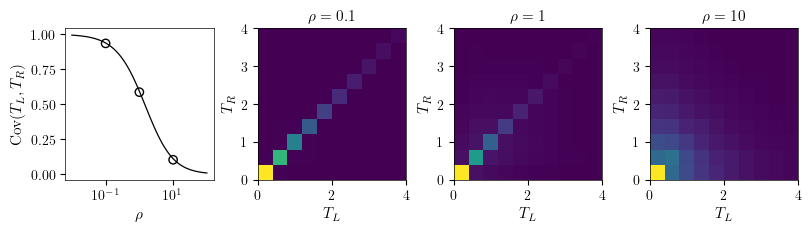

In [25]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2.20), layout="constrained")
axs = axs.flat

# equilibrium models
for ii, rho in enumerate([0.1, 1, 10]):
    x = np.linspace(0, 4, 11)
    TL, TR = equil_model[rho]
    Z = np.histogram2d(TL, TR, bins=(x, x), density=True)[0]
    _x = (x[:-1] + x[1:]) / 2
    X, Y = np.meshgrid(_x, _x)
    axs[ii + 1].set_title(rf"$\rho={rho}$")
    axs[ii + 1].pcolormesh(X, Y, Z, cmap=plt.colormaps['viridis'], norm="linear")
    axs[ii + 1].set_xlabel("$T_L$")
    axs[ii + 1].set_ylabel("$T_R$")

for idx, model in zip([0, 4, 8], [equil_model]):
    rs = np.logspace(-2, 2, 100)
    cvs = (rs + 18) / (rs ** 2 + 13 * rs + 18)
    axs[idx].plot(rs, cvs, color="black", lw=0.9, label="equil")
    for rho in rhos:
        TL, TR = model[rho]
        stat = np.cov(TL, TR)[0, 1] / (np.mean([TL, TR]) ** 2)
        axs[idx].scatter([rho], [stat], marker="o", 
                         color="black", facecolor="none")
    axs[idx].set_xscale("log")
    axs[idx].set_ylabel(r"$\operatorname{Cov}(T_L, T_R)$")
    axs[idx].set_xlabel(r"$\rho$")


plt.savefig("extra_figures/equil_joint_distr.png", dpi=244)

In [71]:
growth_model = {}
epochs = [(0, 10), (2, 1)]
for rho in rhos:
    TL, TR = np.array([dpluspy.backward.noneq_two_locus_coal(epochs, rho) for _ in range(100000)]).T
    growth_model[rho] = (TL, TR)

In [72]:
contraction_model = {}
epochs = [(0, 0.1), (0.2, 1)]
for rho in rhos:
    TL, TR = np.array([dpluspy.backward.noneq_two_locus_coal(epochs, rho) for _ in range(100000)]).T
    contraction_model[rho] = (TL, TR)

In [76]:
rs = np.logspace(-2, 2, 100)
yy = moments.LD.Demographics1D.snm(rho=rs, theta=1)
t2 = yy.H()[0] ** 2
equil_analytic = yy.H2(0) / t2 - 1

yy = moments.LD.Demographics1D.two_epoch([10, 2], rho=rs, theta=1)
H = yy.H()[0]
H2 = H ** 2
growth_analytic = yy.H2(0) / H2 - 1

yy = moments.LD.Demographics1D.two_epoch([0.1, 0.2], rho=rs, theta=1)
t2 = yy.H()[0] ** 2
contraction_analytic = yy.H2(0) / t2 - 1


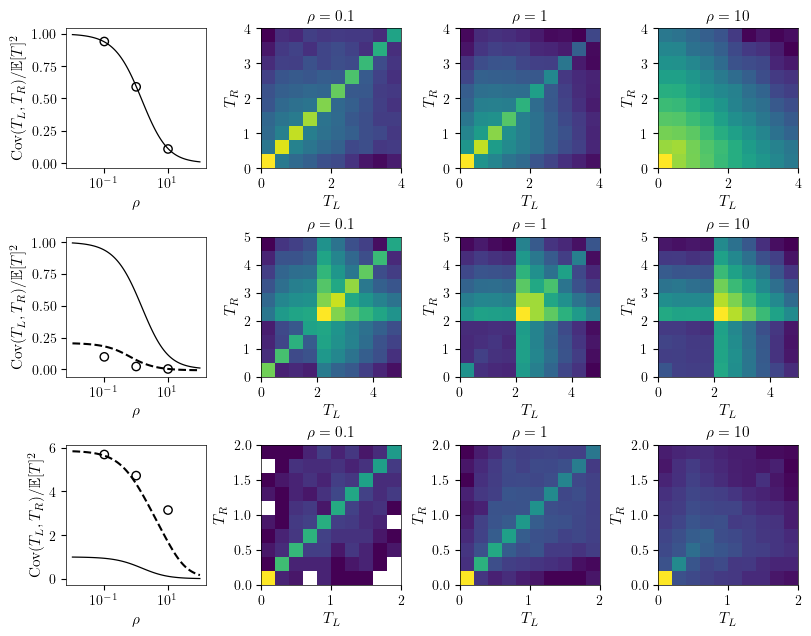

In [80]:
fig, axs = plt.subplots(3, 4, figsize=(8, 6.25), layout="constrained")
axs = axs.flat

# equilibrium models
for ii, rho in enumerate([0.1, 1, 10]):
    x = np.linspace(0, 4, 11)
    TL, TR = equil_model[rho]
    Z = np.histogram2d(TL, TR, bins=(x, x), density=True)[0]
    _x = (x[:-1] + x[1:]) / 2
    X, Y = np.meshgrid(_x, _x)
    axs[ii + 1].set_title(rf"$\rho={rho}$")
    axs[ii + 1].pcolormesh(X, Y, Z, cmap=plt.colormaps['viridis'], norm="log")
    axs[ii + 1].set_xlabel("$T_L$")
    axs[ii + 1].set_ylabel("$T_R$")

# growth models
for ii, rho in enumerate([0.1, 1, 10]):
    x = np.linspace(0, 5, 11)
    TL, TR = growth_model[rho]
    Z = np.histogram2d(TL, TR, bins=(x, x), density=True)[0]
    _x = (x[:-1] + x[1:]) / 2
    X, Y = np.meshgrid(_x, _x)
    axs[ii + 5].set_title(rf"$\rho={rho}$")
    axs[ii + 5].pcolormesh(X, Y, Z, cmap=plt.colormaps['viridis'], norm="log")
    axs[ii + 5].set_xlabel("$T_L$")
    axs[ii + 5].set_ylabel("$T_R$")

# contraction models
for ii, rho in enumerate([0.1, 1, 10]):
    x = np.linspace(0, 2, 11)
    TL, TR = contraction_model[rho]
    Z = np.histogram2d(TL, TR, bins=(x, x), density=True)[0]
    _x = (x[:-1] + x[1:]) / 2
    X, Y = np.meshgrid(_x, _x)
    axs[ii + 9].set_title(rf"$\rho={rho}$")
    axs[ii + 9].pcolormesh(X, Y, Z, cmap=plt.colormaps['viridis'], norm="log")
    axs[ii + 9].set_xlabel("$T_L$")
    axs[ii + 9].set_ylabel("$T_R$")

for idx, model in zip([0, 4, 8], [equil_model, growth_model, contraction_model]):
    cvs = (rs + 18) / (rs ** 2 + 13 * rs + 18)
    axs[idx].plot(rs, cvs, color="black", lw=0.9, label="equil")
    for rho in rhos:
        TL, TR = model[rho]
        stat = np.cov(TL, TR)[0, 1] / (np.mean([TL, TR]) ** 2)
        axs[idx].scatter([rho], [stat], marker="o", 
                         color="black", facecolor="none")
    axs[idx].set_xscale("log")
    axs[idx].set_ylabel(r"$\operatorname{Cov}(T_L, T_R) / \mathbb{E}[T]^2 $")
    axs[idx].set_xlabel(r"$\rho$")

for idx, model in zip([4, 8], [growth_analytic, contraction_analytic]):
    axs[idx].plot(rs, model, "--", color="black", )

plt.savefig("extra_figures/joint_distr.png", dpi=244)

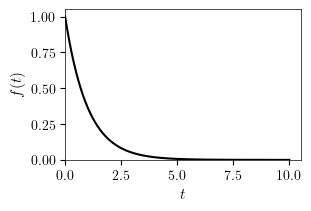

In [14]:
fig, ax = plt.subplots(figsize=(3, 2), layout="constrained")
xs = np.linspace(0, 10, 1000)
ys = scipy.stats.expon.pdf(xs)
plt.plot(xs, ys, color="black")
ax.set_xlim(0, )
ax.set_ylim(0, )
ax.set_ylabel("$f(t)$")
ax.set_xlabel("$t$")
plt.savefig("extra_figures/expon.png", dpi=244)